In [1]:
import pandas as pd
import numpy as np

In [2]:
data_path = "/content/USA_Housing.csv"
df = pd.read_csv(data_path)

In [3]:
X = np.column_stack([
    df['Avg. Area Income'],
    df['Avg. Area House Age'],
    df['Avg. Area Number of Rooms'],
    df['Avg. Area Number of Bedrooms'],
    df['Area Population']
])

y = df['Price']

In [4]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (5000, 5)
y shape: (5000,)


**Multiple Linear Regression**

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
model_multiple = LinearRegression()
model_multiple.fit(X,y)

LinearRegression()

In [7]:
intercept = model_multiple.intercept_
coefficients = model_multiple.coef_

print("Model Equation:")
print(f"Price = {intercept:.2f} "
      f"+ {coefficients[0]:.2f} × Avg_Area_Income "
      f"+ {coefficients[1]:.2f} × Avg_Area_House_Age "
      f"+ {coefficients[2]:.2f} × Avg_Area_Number_of_Rooms "
      f"+ {coefficients[3]:.2f} × Avg_Area_Number_of_Bedrooms "
      f"+ {coefficients[4]:.2f} × Area_Population")

Model Equation:
Price = -2637299.03 + 21.58 × Avg_Area_Income + 165637.03 × Avg_Area_House_Age + 120659.95 × Avg_Area_Number_of_Rooms + 1651.14 × Avg_Area_Number_of_Bedrooms + 15.20 × Area_Population


In [8]:
y_pred = model_multiple.predict(X)

print("First 5 predictions on test set:")
print(f"{'Actual':<15} {'Predicted':<15} {'Error':<15}")
print("="*45)
for i in range(5):
    actual = y.iloc[i]
    predicted = y_pred[i]
    error = abs(actual - predicted)
    print(f"${actual:<14,.2f} ${predicted:<14,.2f} ${error:<14,.2f}")

First 5 predictions on test set:
Actual          Predicted       Error          
$1,059,033.56   $1,223,847.04   $164,813.48    
$1,505,890.91   $1,494,937.69   $10,953.22     
$1,058,987.99   $1,253,016.75   $194,028.76    
$1,260,616.81   $1,121,224.07   $139,392.74    
$630,943.49     $845,388.77     $214,445.28    


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model_linear = LinearRegression()
model_linear.fit(X, y)
y_pred_linear = model_linear.predict(X)

print(f"R² = {r2_score(y, y_pred_linear):.3f}")

R² = 0.918


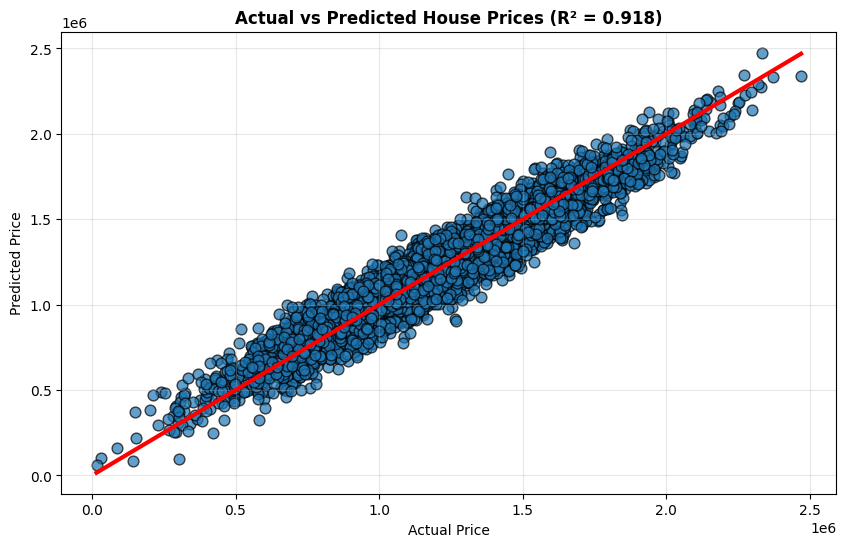

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.figure(figsize=(10,6))

# Scatter plot
plt.scatter(y, y_pred, s=60, edgecolors='black', alpha=0.7)

# Perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r-', linewidth=3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted House Prices (R² = {r2_score(y, y_pred):.3f})", fontweight='bold')

plt.grid(True, alpha=0.3)
plt.show()

**Polynomial Regression**

In [68]:
features = [
    'Avg. Area Income',
    'Avg. Area House Age',
    'Avg. Area Number of Rooms',
    'Avg. Area Number of Bedrooms',
    'Area Population'
]

X = df[features]
y = df['Price']

In [69]:
from sklearn.preprocessing import PolynomialFeatures

poly_example = PolynomialFeatures(degree=2)
sample = np.array([[2]])
transformed = poly_example.fit_transform(sample) # Create polynomial features

print("Input: X = 2")
print(f"Output: {transformed[0]}")
print(f"Which is: [1, X, X², X³] = [1, 2, 4, 8]")

Input: X = 2
Output: [1. 2. 4.]
Which is: [1, X, X², X³] = [1, 2, 4, 8]


Feature Explosion with Multiple Features

In [52]:
# Example: 5 features with degree 2
sample_multi = np.array([[1, 2, 3, 4, 5]])
poly_multi = PolynomialFeatures(degree=2)
transformed_multi = poly_multi.fit_transform(sample_multi)

print(f"Original: 5 features")
print(f"After degree 2: {transformed_multi.shape[1]} features")
print(f"\nFeatures: {poly_multi.get_feature_names_out()}")

Original: 5 features
After degree 2: 21 features

Features: ['1' 'x0' 'x1' 'x2' 'x3' 'x4' 'x0^2' 'x0 x1' 'x0 x2' 'x0 x3' 'x0 x4'
 'x1^2' 'x1 x2' 'x1 x3' 'x1 x4' 'x2^2' 'x2 x3' 'x2 x4' 'x3^2' 'x3 x4'
 'x4^2']


Try Different Degrees

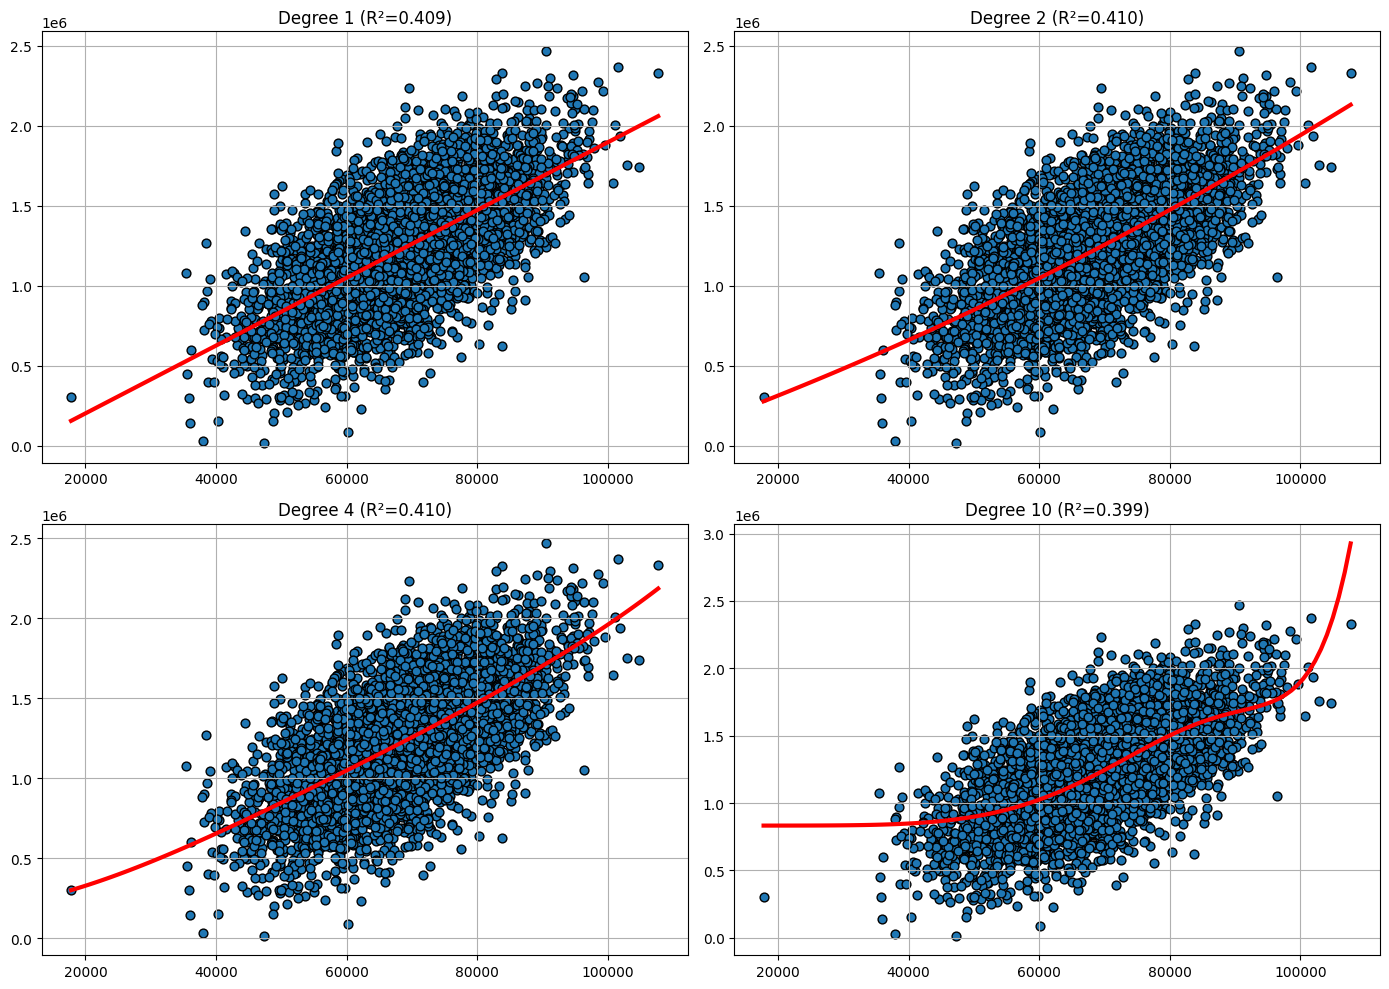

In [53]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use ONE feature for visualization
X = df[['Avg. Area Income']].values
y = df['Price'].values

# Compare polynomial degrees
degrees = [1, 2, 4, 10]

# Create smooth x values for plotting
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, degree in enumerate(degrees):

    poly = PolynomialFeatures(degree=degree)

    X_poly = poly.fit_transform(X)
    X_plot_poly = poly.transform(X_plot)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_plot = model.predict(X_plot_poly)

    r2 = r2_score(y, model.predict(X_poly))

    axes[i].scatter(X, y, s=40, edgecolors='black')
    axes[i].plot(X_plot, y_plot, 'r-', linewidth=3)

    axes[i].set_title(f'Degree {degree} (R²={r2:.3f})')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Overfitting Problem

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Train: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

Train: 3500 samples
Test: 1500 samples


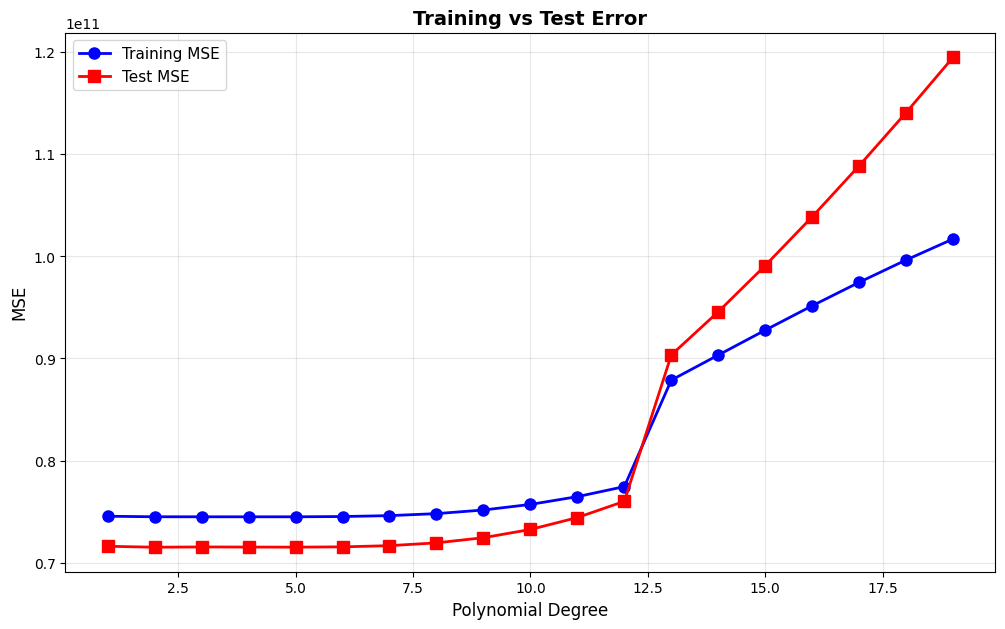

Training MSE: keeps decreasing
Test MSE: goes down then UP (overfitting starts)


In [55]:
# Test degrees 1 to 20
degrees_test = range(1, 20)
train_errors = []
test_errors = []

for degree in degrees_test:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_errors.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_errors.append(mean_squared_error(y_test, model.predict(X_test_poly)))

# Plot
plt.figure(figsize=(12, 7))
plt.plot(degrees_test, train_errors, 'bo-', linewidth=2, markersize=8, label='Training MSE')
plt.plot(degrees_test, test_errors, 'rs-', linewidth=2, markersize=8, label='Test MSE')
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Training vs Test Error', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("Training MSE: keeps decreasing")
print("Test MSE: goes down then UP (overfitting starts)")

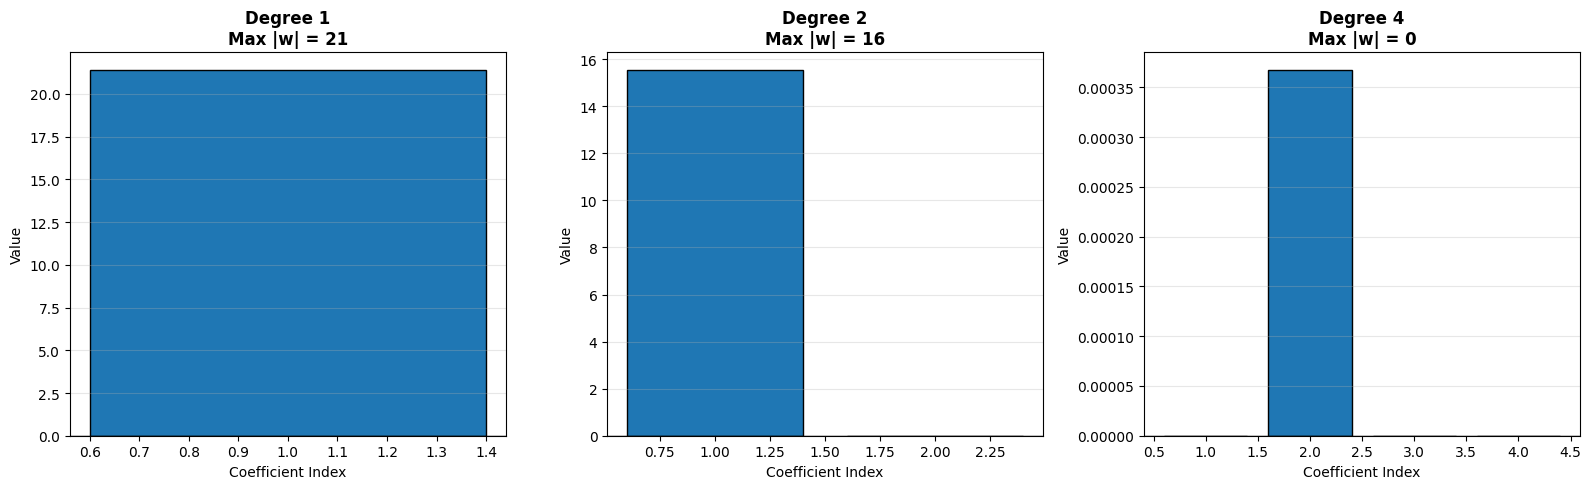

Degree 10: Coefficients EXPLODE to thousands/millions!
Large coefficients → Sharp wiggles → Overfitting


In [60]:
# Show coefficient growth
degrees_coef = [1, 2, 4]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, degree in enumerate(degrees_coef):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    coeffs = model.coef_[1:]  # Skip intercept
    axes[i].bar(range(1, len(coeffs)+1), coeffs, edgecolor='black')
    axes[i].set_title(f'Degree {degree}\nMax |w| = {np.max(np.abs(coeffs)):,.0f}', fontweight='bold')
    axes[i].set_xlabel('Coefficient Index')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3, axis='y')
    axes[i].axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

print("Degree 10: Coefficients EXPLODE to thousands/millions!")
print("Large coefficients → Sharp wiggles → Overfitting")

Regularization
Ridge (L2): Loss = Bsae_Loss + α × Σwᵢ²

Lasso (L1): Loss = Bsae_Loss + α × Σ|wᵢ|

In [67]:
from sklearn.linear_model import Ridge

degree = 2
alpha = 10

poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# No regularization
model_no_reg = LinearRegression()
model_no_reg.fit(X_train_poly, y_train)

# Ridge
model_ridge = Ridge(alpha=alpha)
model_ridge.fit(X_train_poly, y_train)

# Evaluate
test_r2_no_reg = r2_score(y_test, model_no_reg.predict(X_test_poly))
test_r2_ridge = r2_score(y_test, model_ridge.predict(X_test_poly))

print(f"Degree {degree}:")
print(f"Without regularization: R² = {test_r2_no_reg:.3f}")
print(f"With Ridge (α={alpha}):  R² = {test_r2_ridge:.3f}")

Degree 2:
Without regularization: R² = 0.394
With Ridge (α=10):  R² = 0.394


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.30621e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


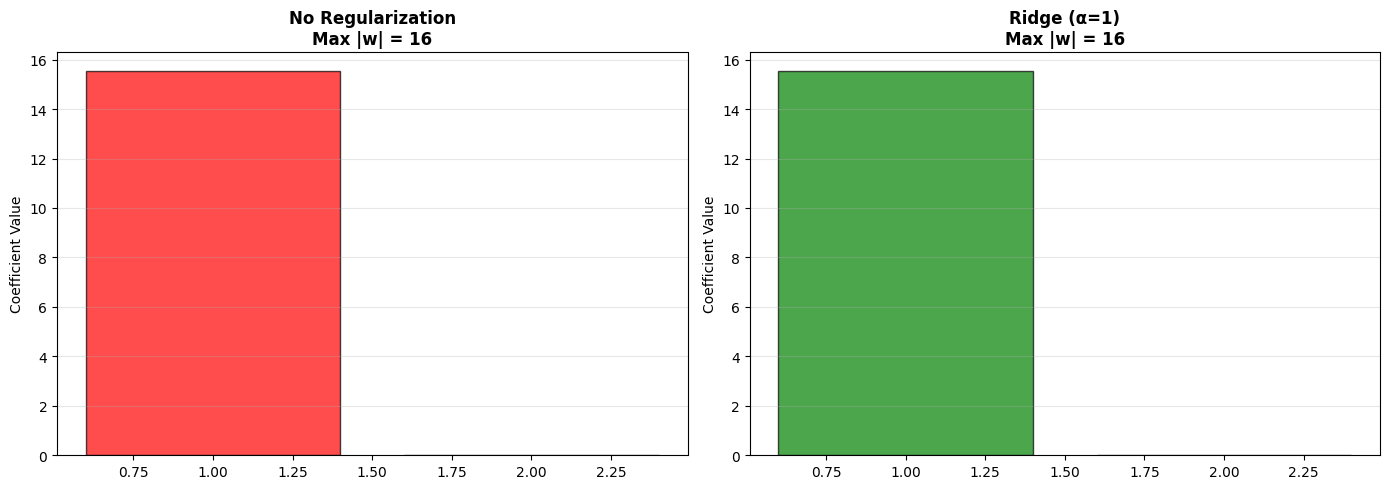

Ridge keeps coefficients SMALL → Better generalization


In [63]:
# Compare coefficients
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

coeffs_no_reg = model_no_reg.coef_[1:]
coeffs_ridge = model_ridge.coef_[1:]

ax1.bar(range(1, len(coeffs_no_reg)+1), coeffs_no_reg, edgecolor='black', color='red', alpha=0.7)
ax1.set_title(f'No Regularization\nMax |w| = {np.max(np.abs(coeffs_no_reg)):,.0f}', fontweight='bold')
ax1.set_ylabel('Coefficient Value')
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(range(1, len(coeffs_ridge)+1), coeffs_ridge, edgecolor='black', color='green', alpha=0.7)
ax2.set_title(f'Ridge (α={alpha})\nMax |w| = {np.max(np.abs(coeffs_ridge)):,.0f}', fontweight='bold')
ax2.set_ylabel('Coefficient Value')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Ridge keeps coefficients SMALL → Better generalization")

Ridge vs Lasso

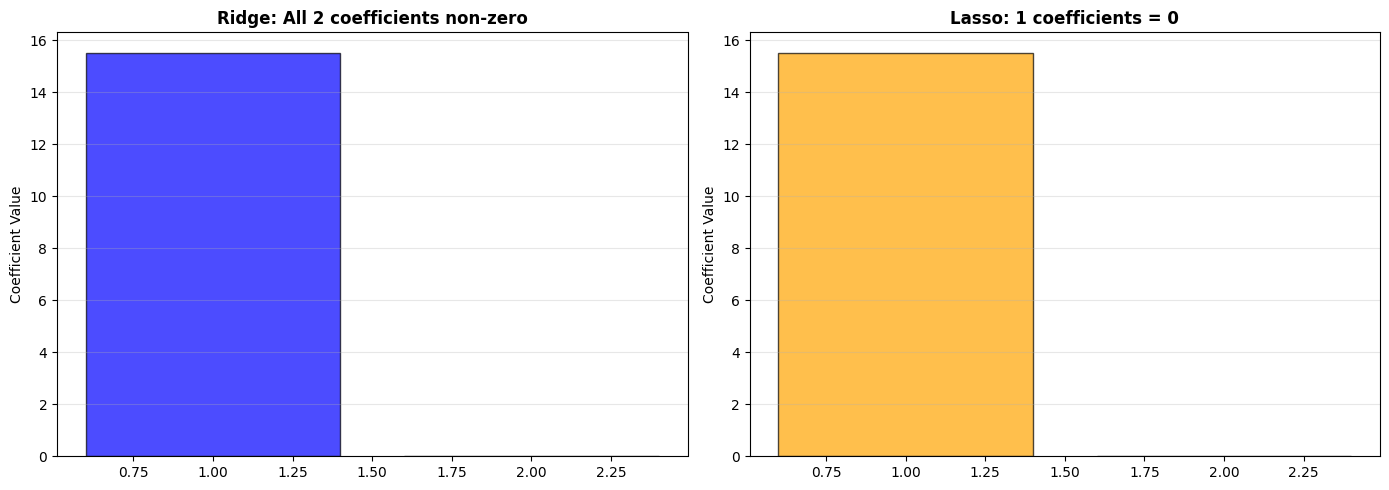

Ridge: Shrinks all coefficients
Lasso: Sets 1 coefficients to EXACTLY zero (feature selection)


In [64]:
# Lasso regularization
from sklearn.linear_model import Lasso

model_lasso = Lasso(alpha=0.001, max_iter=10000)
model_lasso.fit(X_train_poly, y_train)

coeffs_lasso = model_lasso.coef_[1:]
zero_count = np.sum(np.abs(coeffs_lasso) < 0.0001)

# Compare
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(coeffs_ridge)+1), coeffs_ridge, edgecolor='black', color='blue', alpha=0.7)
ax1.set_title(f'Ridge: All {len(coeffs_ridge)} coefficients non-zero', fontweight='bold')
ax1.set_ylabel('Coefficient Value')
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(range(1, len(coeffs_lasso)+1), coeffs_lasso, edgecolor='black', color='orange', alpha=0.7)
ax2.set_title(f'Lasso: {zero_count} coefficients = 0', fontweight='bold')
ax2.set_ylabel('Coefficient Value')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Ridge: Shrinks all coefficients")
print(f"Lasso: Sets {zero_count} coefficients to EXACTLY zero (feature selection)")

Alpha Tuning

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.30621e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.30621e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.30621e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.30621e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.30621e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

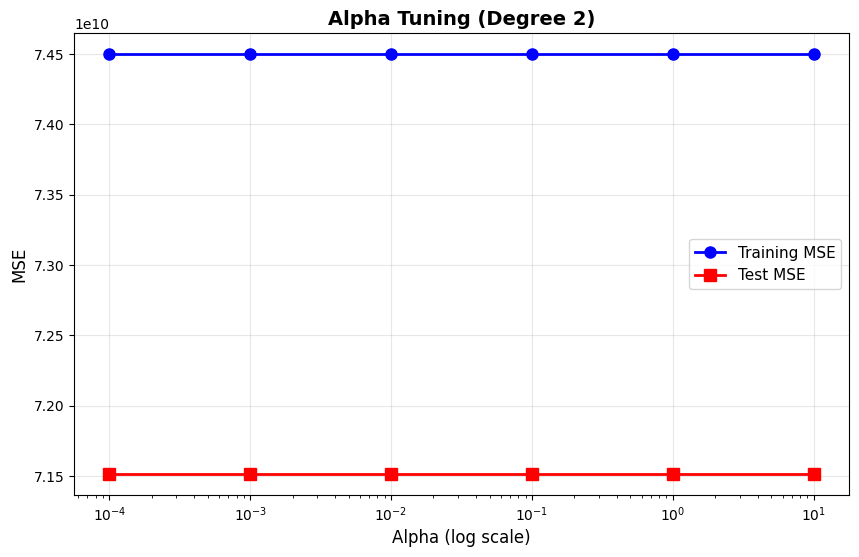

Best alpha: 10


In [65]:
# Find best alpha
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
degree = 2

poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

train_mses = []
test_mses = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)

    train_mses.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_mses.append(mean_squared_error(y_test, model.predict(X_test_poly)))

best_alpha = alphas[np.argmin(test_mses)]

plt.figure(figsize=(10, 6))
plt.plot(alphas, train_mses, 'bo-', linewidth=2, markersize=8, label='Training MSE')
plt.plot(alphas, test_mses, 'rs-', linewidth=2, markersize=8, label='Test MSE')
plt.xscale('log')
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title(f'Alpha Tuning (Degree {degree})', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best alpha: {best_alpha}")

GridSearchCV

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Create pipeline
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('model', Ridge())
])

# Define search space
param_grid = {
    'poly__degree': [1, 2, 3],
    'model__alpha': [0.1, 1, 10, 100]
}

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

print(f"Best degree: {grid.best_params_['poly__degree']}")
print(f"Best alpha:  {grid.best_params_['model__alpha']}")
print(f"\nTest R²: {r2_score(y_test, grid.predict(X_test)):.4f}")

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.65216e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.60616e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.64504e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.63181e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.63014e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

Best degree: 2
Best alpha:  100

Test R²: 0.3940


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.40593e-30): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.43791e-30): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.43113e-30): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.42918e-30): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.30621e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


KNN **Regression**

In [76]:
features = [
    'Avg. Area Income',
    'Avg. Area House Age',
    'Avg. Area Number of Rooms',
    'Avg. Area Number of Bedrooms',
    'Area Population'
]

X = df[features]
y = df['Price']

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

Train: 4000 samples
Test: 1000 samples


In [78]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

knn_no_scale = KNeighborsRegressor(n_neighbors=30)
knn_no_scale.fit(X_train, y_train)
y_pred_no_scale = knn_no_scale.predict(X_test)

print("WITHOUT Scaling:")
print(f"R² = {r2_score(y_test, y_pred_no_scale):.3f}")

WITHOUT Scaling:
R² = 0.549


In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])

pipeline.fit(X_train, y_train)
y_pred_scaled = pipeline.predict(X_test)

print("WITH Scaling (Pipeline):")
print(f"R² = {r2_score(y_test, y_pred_scaled):.3f}")

WITH Scaling (Pipeline):
R² = 0.869


**Choosing K**

In [80]:
import matplotlib.pyplot as plt

k_values = range(1, 31)
train_errors = []
test_errors = []

for k in k_values:
    pipeline_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k))
    ])
    pipeline_k.fit(X_train, y_train)

    train_errors.append(mean_squared_error(y_train, pipeline_k.predict(X_train)))
    test_errors.append(mean_squared_error(y_test, pipeline_k.predict(X_test)))

In [81]:
best_k = k_values[np.argmin(test_errors)]
print(f"Best K: {best_k}")
print(f"Best Test MSE: ${min(test_errors):,.0f}")

Best K: 9
Best Test MSE: $15,311,227,372


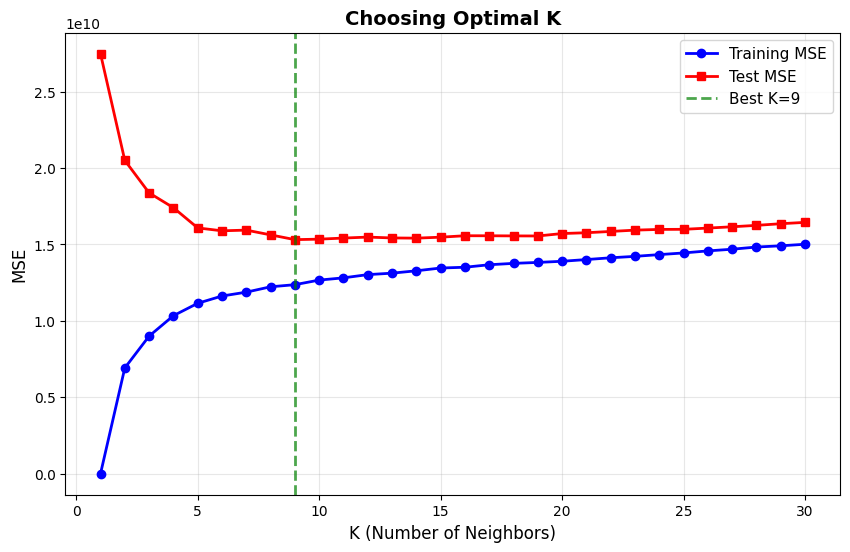

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, 'bo-', label='Training MSE', linewidth=2, markersize=6)
plt.plot(k_values, test_errors, 'rs-', label='Test MSE', linewidth=2, markersize=6)
plt.axvline(best_k, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Choosing Optimal K', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

**Save and Load Model**

In [83]:
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=best_k))
])

final_pipeline.fit(X_train, y_train)

print(f"Trained final model with K={best_k}")
print(f"Test R²: {r2_score(y_test, final_pipeline.predict(X_test)):.3f}")

Trained final model with K=9
Test R²: 0.876


In [84]:
import joblib

joblib.dump(final_pipeline, 'house_price_knn.pkl')

['house_price_knn.pkl']

In [85]:
loaded_pipeline = joblib.load('house_price_knn.pkl')

In [86]:
test_house = [[69500, 5, 7, 4, 23000]]

prediction = loaded_pipeline.predict(test_house)[0]

print(f"Predicted Price: ${prediction:,.0f}")

Predicted Price: $857,332


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
